# Exploring the RELLIS-3D dataset

Before using a dataset it is worth knowing exactly what is inside it. This notebook answers
simple, practical questions about RELLIS-3D:

- How many images, labels and poses does each sequence have? Do they line up?
- How big are the images, and what do the label files actually contain?
- Which terrain classes appear, and how many pixels does each one cover?
- If we split the classes into *traversable* and *not traversable*, how balanced is that split?
- How far did the robot drive in each sequence?

At the **end of the notebook** there is a written explanation of the dataset format and of how
every file is used in this project.

The code is written to be easy to read: small steps, plain loops, and printed results.

## 1. Settings

In [1]:
from pathlib import Path

DATA_ROOT = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/Rellis_3D')

# Counting pixels in every label image is slow (there are thousands of them).
# SAMPLE_EVERY = 5 means "use every 5th labelled image", which is plenty for statistics.
# Set it to 1 if you want to count every single labelled image (slower).
SAMPLE_EVERY = 5

# The official RELLIS class id -> name mapping
CLASS_NAMES = {
    0: 'void',      1: 'dirt',     3: 'grass',    4: 'tree',      5: 'pole',
    6: 'water',     7: 'sky',      8: 'vehicle',  9: 'object',   10: 'asphalt',
    12: 'building', 15: 'log',    17: 'person',  18: 'fence',    19: 'bush',
    23: 'concrete', 27: 'barrier', 31: 'puddle',  33: 'mud',      34: 'rubble',
}

# How this project groups the classes for traversability
TRAVERSABLE_IDS = [1, 3, 10, 23, 31, 33]   # dirt, grass, asphalt, concrete, puddle, mud
IGNORE_IDS      = [0, 7]                    # void, sky -- not scored at all
# everything else counts as an obstacle

assert DATA_ROOT.is_dir(), f'dataset not found at {DATA_ROOT}'
print('dataset root:', DATA_ROOT)

dataset root: s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\Rellis_3D


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# find the sequence folders (00000, 00001, ...)
sequences = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print('sequences found:', sequences)

sequences found: ['00000', '00001', '00002', '00003', '00004']


## 2. What files does one sequence contain?

Every sequence folder has the same structure, so we look at the first one.

In [3]:
example_seq = DATA_ROOT / sequences[0]
print('contents of', example_seq.name, ':\n')
for item in sorted(example_seq.iterdir()):
    if item.is_dir():
        n_files = len(list(item.iterdir()))
        print(f'  [folder] {item.name:35s} {n_files} files')
    else:
        size_kb = item.stat().st_size / 1024
        print(f'  [file]   {item.name:35s} {size_kb:8.1f} KB')

contents of 00000 :

  [file]   calib.txt                                0.3 KB
  [file]   camera_info.txt                          0.0 KB
  [file]   poses.txt                              323.9 KB
  [folder] pylon_camera_node                   2847 files
  [folder] pylon_camera_node_label_id          1201 files
  [file]   transforms.yaml                          0.2 KB


In [4]:
# peek inside the small text files
print('--- camera_info.txt (camera intrinsics) ---')
print((example_seq / 'camera_info.txt').read_text().strip())

print('\n--- poses.txt (first 2 lines) ---')
pose_text = (example_seq / 'poses.txt').read_text().splitlines()
for line in pose_text[:2]:
    print(line)
print(f'... {len(pose_text)} lines in total')

print('\n--- transforms.yaml (camera <-> LiDAR mounting) ---')
print((example_seq / 'transforms.yaml').read_text().strip())

print('\n--- calib.txt ---')
print((example_seq / 'calib.txt').read_text().strip())

--- camera_info.txt (camera intrinsics) ---
2813.643275 2808.326079 969.285772 624.049972

--- poses.txt (first 2 lines) ---
-0.494343 -0.869248 0.00570628 0.271283 0.867473 -0.493734 -0.0609658 -0.478529 0.0558118 -0.025188 0.998124 0.0919406
-0.494343 -0.869248 0.00570628 0.271283 0.867473 -0.493734 -0.0609658 -0.478529 0.0558118 -0.025188 0.998124 0.0919406
... 2847 lines in total

--- transforms.yaml (camera <-> LiDAR mounting) ---
os1_cloud_node-pylon_camera_node:
  q:
    w: -0.50507811
    x: 0.51206185
    y: 0.49024953
    z: -0.49228464
  t:
    x: -0.13165462
    y: 0.03870398
    z: -0.17253834

--- calib.txt ---
P0: 1.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 1.0 0.0
P1: 1.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 1.0 0.0
P2: 1.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 1.0 0.0
P3: 1.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 1.0 0.0
Tr: 1.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 1.0 0.0


## 3. How many images, labels and poses are in each sequence?

This is the most important sanity check of the whole project. The pose-projection step assumes
that **image number `i` matches pose line number `i`**, so those two counts must be equal.

Note that only *some* images have a semantic label: RELLIS labelled roughly every second frame.

In [5]:
summary = []   # one row per sequence

for seq in sequences:
    seq_dir = DATA_ROOT / seq
    image_files = sorted((seq_dir / 'pylon_camera_node').glob('*.jpg'))
    label_files = sorted((seq_dir / 'pylon_camera_node_label_id').glob('*.png'))
    pose_lines = [line for line in (seq_dir / 'poses.txt').read_text().splitlines() if line.strip()]

    # a label belongs to an image when the file name (without extension) is the same
    image_names = set(p.stem for p in image_files)
    matched_labels = sum(1 for p in label_files if p.stem in image_names)

    summary.append({
        'sequence': seq,
        'images': len(image_files),
        'labels': len(label_files),
        'matched': matched_labels,
        'poses': len(pose_lines),
    })

print(f"{'seq':<9}{'images':>8}{'labels':>8}{'matched':>9}{'poses':>8}   {'images==poses?':>15}")
print('-' * 62)
for row in summary:
    ok = 'YES' if row['images'] == row['poses'] else '*** NO ***'
    print(f"{row['sequence']:<9}{row['images']:>8}{row['labels']:>8}{row['matched']:>9}"
          f"{row['poses']:>8}   {ok:>15}")

total_images = sum(r['images'] for r in summary)
total_labels = sum(r['labels'] for r in summary)
print('-' * 62)
print(f"{'TOTAL':<9}{total_images:>8}{total_labels:>8}")
print(f'\nOnly {100 * total_labels / total_images:.0f}% of the images have a semantic label.')

seq        images  labels  matched   poses    images==poses?
--------------------------------------------------------------
00000        2847    1200     1200    2847               YES
00001        2319    1161     1161    2319               YES
00002        4147    2074     2074    4147               YES
00003        2184     900      900    2184               YES
00004        2059     899      899    2059               YES
--------------------------------------------------------------
TOTAL       13556    6234

Only 46% of the images have a semantic label.


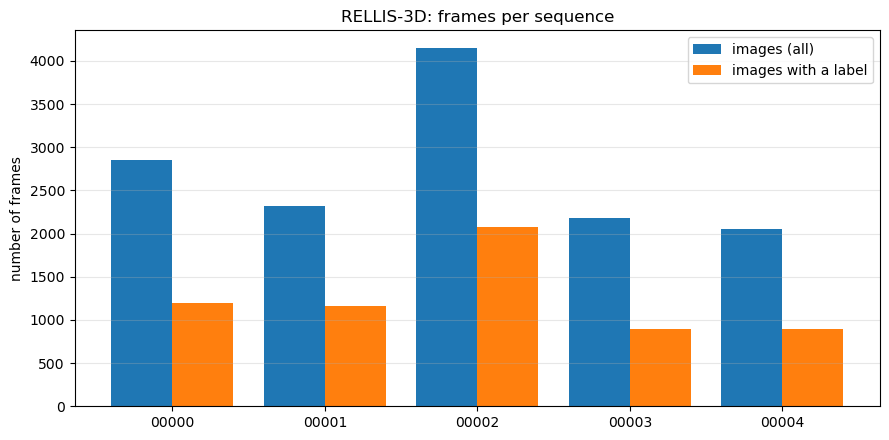

In [6]:
# bar chart: images vs labels per sequence
x = np.arange(len(summary))
images_per_seq = [r['images'] for r in summary]
labels_per_seq = [r['labels'] for r in summary]

plt.figure(figsize=(9, 4.5))
plt.bar(x - 0.2, images_per_seq, 0.4, label='images (all)')
plt.bar(x + 0.2, labels_per_seq, 0.4, label='images with a label')
plt.xticks(x, [r['sequence'] for r in summary])
plt.ylabel('number of frames')
plt.title('RELLIS-3D: frames per sequence')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. What does one image and one label file look like?

The RGB image is an ordinary colour photo. The label file looks black when opened normally,
because it stores a **class number** (0--34) in every pixel rather than a colour.

In [7]:
# take the first labelled frame of the first sequence
seq_dir = DATA_ROOT / sequences[0]
label_files = sorted((seq_dir / 'pylon_camera_node_label_id').glob('*.png'))
example_label_path = label_files[0]
example_image_path = seq_dir / 'pylon_camera_node' / (example_label_path.stem + '.jpg')

image = cv2.imread(str(example_image_path))
label = cv2.imread(str(example_label_path), cv2.IMREAD_UNCHANGED)

print('image file :', example_image_path.name)
print('  shape    :', image.shape, '(height, width, colour channels)')
print('  data type:', image.dtype)
print()
print('label file :', example_label_path.name)
print('  shape    :', label.shape, '(height, width -- no colour channels!)')
print('  data type:', label.dtype)
print('  class ids present:', np.unique(label))
print('  -> which means   :', [CLASS_NAMES.get(c, '?') for c in np.unique(label)])

image file : frame000000-1581624652_750.jpg
  shape    : (1200, 1920, 3) (height, width, colour channels)
  data type: uint8

label file : frame000000-1581624652_750.png
  shape    : (1200, 1920) (height, width -- no colour channels!)
  data type: uint8
  class ids present: [ 3  4  7  8  9 18 19 31 33]
  -> which means   : ['grass', 'tree', 'sky', 'vehicle', 'object', 'fence', 'bush', 'puddle', 'mud']


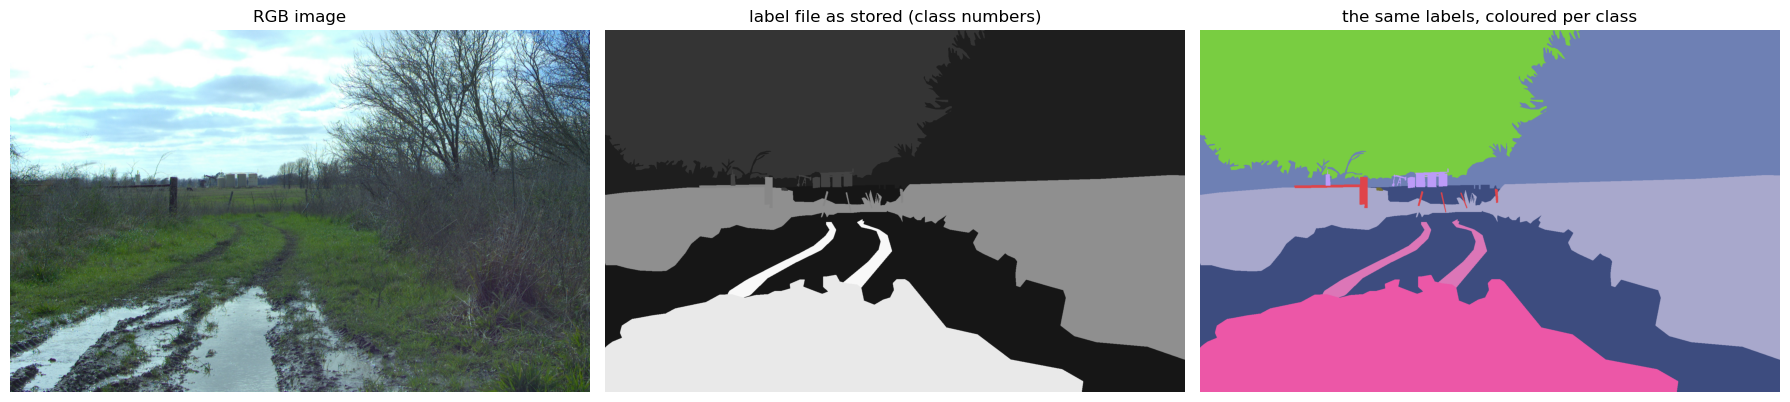

In [8]:
# show the image, the raw label, and the label coloured by class
def colour_the_labels(label_image):
    """Give every class id its own random-but-fixed colour so we can see the segmentation."""
    rng = np.random.RandomState(0)
    palette = rng.randint(40, 255, size=(256, 3)).astype(np.uint8)
    palette[0] = [0, 0, 0]        # void = black
    return palette[label_image]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title('RGB image')
axes[1].imshow(label, cmap='gray', vmin=0, vmax=34)
axes[1].set_title('label file as stored (class numbers)')
axes[2].imshow(colour_the_labels(label))
axes[2].set_title('the same labels, coloured per class')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Counting pixels per class

Now the main question: how much of the dataset is grass, how much is tree, and so on.
We walk through the labelled images and count how often each class number appears.

`np.bincount` counts occurrences of each number very quickly, which is why the loop below is
fast even though each image has more than 2 million pixels.

In [9]:
import time

# pixel_counts[seq][class_id] = number of pixels of that class in that sequence
pixel_counts = {}
frames_per_class = {}      # in how many frames does each class appear at all?
start = time.time()

for seq in sequences:
    seq_dir = DATA_ROOT / seq
    label_files = sorted((seq_dir / 'pylon_camera_node_label_id').glob('*.png'))
    chosen = label_files[::SAMPLE_EVERY]

    counts = np.zeros(256, dtype=np.int64)
    appears = np.zeros(256, dtype=np.int64)
    for path in chosen:
        label_image = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
        this_frame = np.bincount(label_image.ravel(), minlength=256)
        counts += this_frame
        appears += (this_frame > 0).astype(np.int64)

    pixel_counts[seq] = counts
    frames_per_class[seq] = appears
    print(f'{seq}: counted {len(chosen)} labelled frames')

print(f'\nfinished in {time.time() - start:.0f} seconds '
      f'(every {SAMPLE_EVERY}th labelled frame)')

# add all sequences together
total_counts = sum(pixel_counts.values())
total_pixels = total_counts.sum()
print(f'total pixels counted: {total_pixels:,}')

00000: counted 240 labelled frames
00001: counted 233 labelled frames
00002: counted 415 labelled frames
00003: counted 180 labelled frames
00004: counted 180 labelled frames

finished in 27 seconds (every 5th labelled frame)
total pixels counted: 2,875,392,000


In [10]:
# print the class table, biggest class first
present_ids = [i for i in range(256) if total_counts[i] > 0]
present_ids.sort(key=lambda i: total_counts[i], reverse=True)

print(f"{'id':>4}  {'class':<12}{'pixels':>16}{'share':>9}   group")
print('-' * 60)
for class_id in present_ids:
    name = CLASS_NAMES.get(class_id, f'unknown-{class_id}')
    share = 100 * total_counts[class_id] / total_pixels
    if class_id in IGNORE_IDS:
        group = 'ignored'
    elif class_id in TRAVERSABLE_IDS:
        group = 'traversable'
    else:
        group = 'obstacle'
    print(f'{class_id:>4}  {name:<12}{total_counts[class_id]:>16,}{share:>8.2f}%   {group}')

  id  class                 pixels    share   group
------------------------------------------------------------
   3  grass            965,888,253   33.59%   traversable
   7  sky              851,528,168   29.61%   ignored
  19  bush             501,324,652   17.44%   obstacle
   4  tree             400,715,493   13.94%   obstacle
  33  mud               63,276,492    2.20%   traversable
  23  concrete          44,922,060    1.56%   traversable
  31  puddle            20,915,873    0.73%   traversable
  27  barrier           10,310,520    0.36%   obstacle
  34  rubble             5,493,612    0.19%   obstacle
   6  water              2,321,037    0.08%   obstacle
  17  person             1,837,932    0.06%   obstacle
  10  asphalt            1,754,649    0.06%   traversable
   8  vehicle            1,039,353    0.04%   obstacle
   9  object               970,929    0.03%   obstacle
  15  log                  942,335    0.03%   obstacle
  18  fence                923,053    0.03%   ob

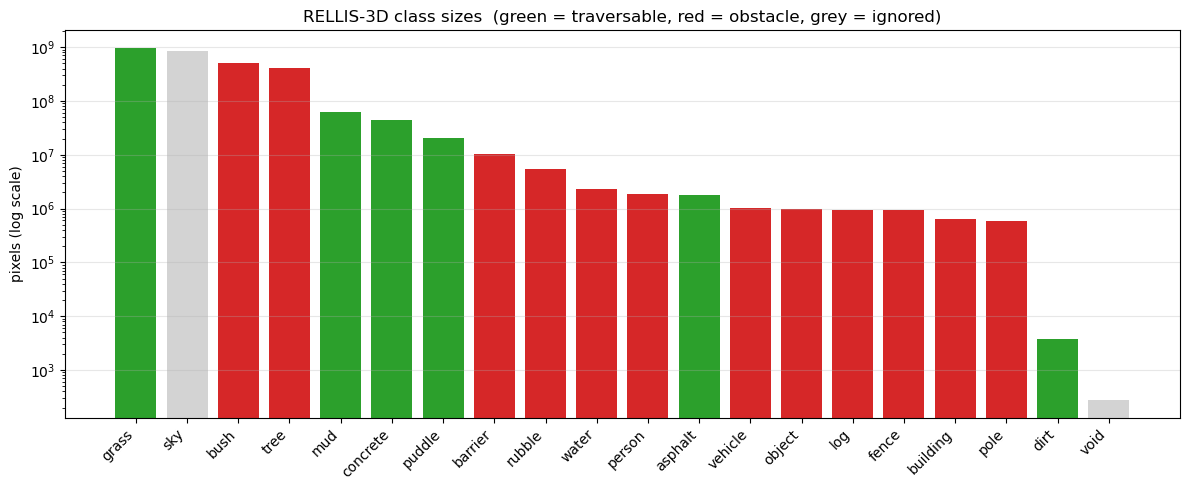

Note the log scale: the largest class has millions of times more pixels than the smallest.
This is the "class imbalance" the RELLIS-3D paper warns about.


In [11]:
# bar chart of class sizes (log scale, because the classes are very unbalanced)
names = [CLASS_NAMES.get(i, str(i)) for i in present_ids]
values = [total_counts[i] for i in present_ids]
colours = []
for i in present_ids:
    if i in IGNORE_IDS:
        colours.append('lightgray')
    elif i in TRAVERSABLE_IDS:
        colours.append('tab:green')
    else:
        colours.append('tab:red')

plt.figure(figsize=(12, 5))
plt.bar(names, values, color=colours)
plt.yscale('log')
plt.ylabel('pixels (log scale)')
plt.title('RELLIS-3D class sizes  (green = traversable, red = obstacle, grey = ignored)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Note the log scale: the largest class has millions of times more pixels than the smallest.')
print('This is the "class imbalance" the RELLIS-3D paper warns about.')

## 6. How many pixels are traversable?

This is the number that matters for our evaluation. We group the classes as described in
section 1 and count how many pixels land in each group.

Sky and void are **ignored**: they are not ground at all, so scoring them would only inflate
the results.

total pixels        :    2,875,392,000
  ignored (sky/void):      851,528,445  ( 29.6% of all)
  traversable       :    1,096,761,103  ( 38.1% of all)
  obstacle          :      927,102,452  ( 32.2% of all)

Of the pixels we actually score (ignoring sky and void):
  traversable :  54.2%
  obstacle    :  45.8%

This is the "class balance". A model that blindly says "everything is traversable"
would already be right 54.2% of the time,
which is why accuracy alone is a weak metric and we also report IoU and ROC-AUC.


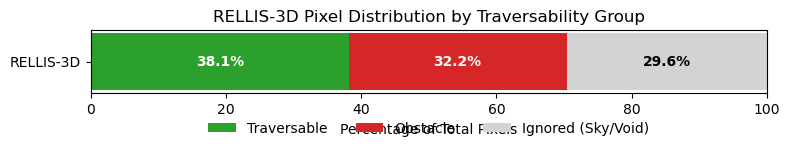

In [14]:
traversable_pixels = sum(total_counts[i] for i in TRAVERSABLE_IDS)
ignored_pixels     = sum(total_counts[i] for i in IGNORE_IDS)
obstacle_pixels    = total_pixels - traversable_pixels - ignored_pixels
scored_pixels      = traversable_pixels + obstacle_pixels

print(f'total pixels        : {total_pixels:>16,}')
print(f'  ignored (sky/void): {ignored_pixels:>16,}  ({100*ignored_pixels/total_pixels:5.1f}% of all)')
print(f'  traversable       : {traversable_pixels:>16,}  ({100*traversable_pixels/total_pixels:5.1f}% of all)')
print(f'  obstacle          : {obstacle_pixels:>16,}  ({100*obstacle_pixels/total_pixels:5.1f}% of all)')
print()
print('Of the pixels we actually score (ignoring sky and void):')
print(f'  traversable : {100 * traversable_pixels / scored_pixels:5.1f}%')
print(f'  obstacle    : {100 * obstacle_pixels / scored_pixels:5.1f}%')
print()
print('This is the "class balance". A model that blindly says "everything is traversable"')
print(f'would already be right {100 * traversable_pixels / scored_pixels:.1f}% of the time,')
print('which is why accuracy alone is a weak metric and we also report IoU and ROC-AUC.')

# Convert to percentages
trav_pct = 100 * traversable_pixels / total_pixels
obs_pct = 100 * obstacle_pixels / total_pixels
ign_pct = 100 * ignored_pixels / total_pixels

plt.figure(figsize=(8, 1.8))

# Horizontal stacked bar
plt.barh(
    ['RELLIS-3D'],
    [trav_pct],
    color='tab:green',
    label='Traversable'
)

plt.barh(
    ['RELLIS-3D'],
    [obs_pct],
    left=[trav_pct],
    color='tab:red',
    label='Obstacle'
)

plt.barh(
    ['RELLIS-3D'],
    [ign_pct],
    left=[trav_pct + obs_pct],
    color='lightgray',
    label='Ignored (Sky/Void)'
)

# Percentage labels
segments = [
    (trav_pct, 0, 'white'),
    (obs_pct, trav_pct, 'white'),
    (ign_pct, trav_pct + obs_pct, 'black')
]

for width, left, text_color in segments:
    if width > 4:  # Don't label tiny segments
        plt.text(
            left + width / 2,
            0,
            f'{width:.1f}%',
            ha='center',
            va='center',
            color=text_color,
            fontsize=10,
            fontweight='bold'
        )

plt.xlim(0, 100)
plt.xlabel('Percentage of Total Pixels')
plt.title('RELLIS-3D Pixel Distribution by Traversability Group')
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()

In [15]:
# the same split, per sequence -- useful when choosing which sequence to hold out
print(f"{'seq':<9}{'traversable':>13}{'obstacle':>13}{'ignored':>13}   {'% traversable*':>15}")
print('-' * 68)
for seq in sequences:
    counts = pixel_counts[seq]
    trav = sum(counts[i] for i in TRAVERSABLE_IDS)
    ign  = sum(counts[i] for i in IGNORE_IDS)
    obst = counts.sum() - trav - ign
    pct  = 100 * trav / (trav + obst)
    print(f'{seq:<9}{trav:>13,}{obst:>13,}{ign:>13,}   {pct:>14.1f}%')
print('\n* as a share of scored pixels (sky and void excluded)')

seq        traversable     obstacle      ignored    % traversable*
--------------------------------------------------------------------
00000      206,126,551  263,002,186   83,831,263             43.9%
00001      216,045,440  148,143,125  172,643,435             59.3%
00002      356,566,449  279,491,240  320,102,311             56.1%
00003      159,213,721  120,628,001  134,878,278             56.9%
00004      158,808,942  115,837,900  140,073,158             57.8%

* as a share of scored pixels (sky and void excluded)


## 7. Which classes appear in which sequence?

Useful to know before choosing a hold-out sequence: if a class only exists in one sequence,
training and testing will see very different terrain.

In [16]:
print(f"{'class':<12}" + ''.join(f'{s:>9}' for s in sequences))
print('-' * (12 + 9 * len(sequences)))
for class_id in present_ids:
    name = CLASS_NAMES.get(class_id, str(class_id))
    row = ''
    for seq in sequences:
        share = 100 * pixel_counts[seq][class_id] / pixel_counts[seq].sum()
        row += f'{share:>8.2f}%' if share > 0 else f"{'-':>9}"
    print(f'{name:<12}' + row)
print('\n(each number is the share of that sequence\'s pixels; "-" means the class never appears)')

class           00000    00001    00002    00003    00004
---------------------------------------------------------
grass          32.33%   36.64%   32.60%   35.83%   31.39%
sky            15.16%   32.16%   33.48%   32.52%   33.78%
bush           14.05%   17.18%   22.39%   13.76%   14.53%
tree           33.06%    9.62%    6.15%   13.70%   12.20%
mud             2.77%    2.54%    0.10%    1.68%    6.36%
concrete            -    0.42%    4.39%    0.07%    0.09%
puddle          2.18%    0.65%    0.02%    0.81%    0.46%
barrier             -    0.49%    0.21%    0.86%    0.51%
rubble          0.00%    0.23%        -    0.43%    0.59%
water               -        -    0.24%        -        -
person          0.15%    0.04%    0.01%    0.17%        -
asphalt             -    0.00%    0.18%        -        -
vehicle         0.01%        -    0.07%    0.07%        -
object          0.06%        -    0.07%        -        -
log                 -    0.04%        -    0.08%    0.09%
fence         

## 8. How far did the robot drive?

`poses.txt` gives the robot's position at every frame, so we can measure the path length by
adding up the distance between consecutive positions.

In [17]:
def read_positions(poses_path):
    """Read poses.txt and return just the (x, y, z) position of every frame."""
    positions = []
    for line in poses_path.read_text().splitlines():
        if not line.strip():
            continue
        numbers = np.array(line.split(), dtype=np.float64)
        matrix = numbers.reshape(3, 4)      # 3x4 matrix [rotation | translation]
        positions.append(matrix[:, 3])      # the last column is the position
    return np.array(positions)

print(f"{'seq':<9}{'frames':>8}{'path length':>14}{'median step':>14}")
print('-' * 46)
all_positions = {}
for seq in sequences:
    positions = read_positions(DATA_ROOT / seq / 'poses.txt')
    all_positions[seq] = positions
    steps = np.linalg.norm(np.diff(positions, axis=0), axis=1)
    print(f'{seq:<9}{len(positions):>8}{steps.sum():>12.1f} m{np.median(steps)*100:>11.1f} cm')

seq        frames   path length   median step
----------------------------------------------
00000        2847       332.2 m       13.0 cm
00001        2319       267.7 m       12.9 cm
00002        4147       482.7 m       12.5 cm
00003        2184       254.0 m       13.2 cm
00004        2059       226.1 m       12.2 cm


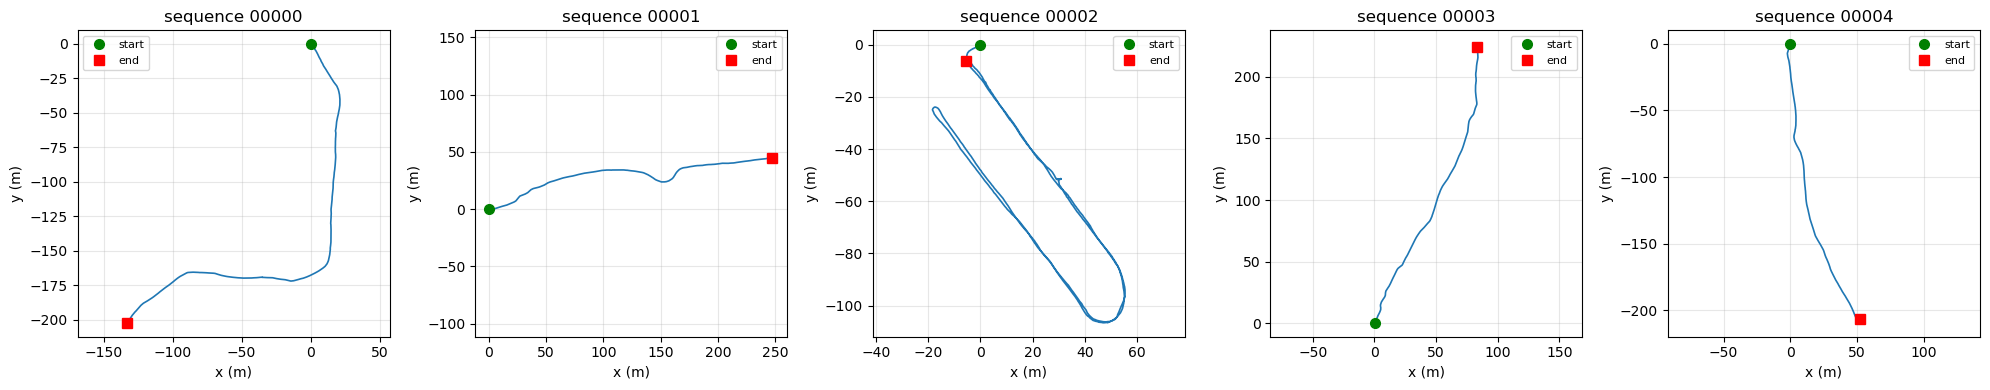

In [18]:
# draw each trajectory from above (x-y plane)
fig, axes = plt.subplots(1, len(sequences), figsize=(4 * len(sequences), 4))
for ax, seq in zip(axes, sequences):
    positions = all_positions[seq]
    ax.plot(positions[:, 0], positions[:, 1], linewidth=1.2)
    ax.plot(positions[0, 0], positions[0, 1], 'go', markersize=7, label='start')
    ax.plot(positions[-1, 0], positions[-1, 1], 'rs', markersize=7, label='end')
    ax.set_title(f'sequence {seq}')
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.axis('equal'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Camera settings of each sequence

In [19]:
print(f"{'seq':<9}{'fx':>12}{'fy':>12}{'cx':>12}{'cy':>12}{'image size':>16}")
print('-' * 74)
for seq in sequences:
    fx, fy, cx, cy = np.loadtxt(DATA_ROOT / seq / 'camera_info.txt').ravel()[:4]
    first_image = sorted((DATA_ROOT / seq / 'pylon_camera_node').glob('*.jpg'))[0]
    height, width = cv2.imread(str(first_image)).shape[:2]
    print(f'{seq:<9}{fx:>12.2f}{fy:>12.2f}{cx:>12.2f}{cy:>12.2f}{f"{width}x{height}":>16}')

print('\nfx, fy = focal length in pixels; cx, cy = the optical centre of the image.')
print('Note: camera_info.txt in this release has NO distortion values, only these four numbers.')

seq                fx          fy          cx          cy      image size
--------------------------------------------------------------------------
00000         2813.64     2808.33      969.29      624.05       1920x1200
00001         2813.64     2808.33      969.29      624.05       1920x1200
00002         2813.64     2808.33      969.29      624.05       1920x1200
00003         2813.64     2808.33      969.29      624.05       1920x1200
00004         2813.64     2808.33      969.29      624.05       1920x1200

fx, fy = focal length in pixels; cx, cy = the optical centre of the image.
Note: camera_info.txt in this release has NO distortion values, only these four numbers.


---

# 10. The dataset explained

This section describes what RELLIS-3D is, what each file contains, and exactly how this
project uses (or deliberately ignores) each one.

## 10.1 What RELLIS-3D is

RELLIS-3D is an **off-road driving dataset**. A wheeled robot (a Clearpath **Warthog**) was
driven around a field/trail environment while recording:

- a forward-facing colour camera (a Basler camera),
- a LiDAR scanner (an Ouster),
- the robot's position over time, estimated by a SLAM system,
- and, for about half the images, a **human-drawn semantic label** for every single pixel.

It was published as a benchmark because most public driving datasets are of city streets,
where the world is tidy: flat roads, painted lines, clear kerbs. Off-road there are no lane
markings, grass and bushes blur into each other, and the same green pixels can be either safe
ground or an impassable shrub.

## 10.2 The folder layout

The data is split into **five sequences** (`00000` to `00004`), each one a separate drive.
Every sequence folder has the same contents:

```
00000/
├── pylon_camera_node/            <- the camera images (.jpg)
├── pylon_camera_node_label_id/   <- the semantic labels (.png)
├── poses.txt                     <- where the robot was, one line per image
├── camera_info.txt               <- camera intrinsics (fx, fy, cx, cy)
├── transforms.yaml               <- how the camera is mounted relative to the LiDAR
└── calib.txt                     <- (empty placeholder in this release)
```

**File naming.** An image called `frame000104-1581624652_750.jpg` encodes the frame number
(`000104`) and the timestamp (`1581624652.750`). Its label, if one exists, has exactly the same
name but ends in `.png`. That shared name is how we match an image to its label.

## 10.3 What each file contains, and how we use it

### `pylon_camera_node/*.jpg` — the camera images
Ordinary colour photos, **1920×1200 pixels**. Everything starts here.

*How we use it:* every image is resized to a 700×700 square and passed through the DINOv2 (or
DINOv3) vision model to obtain features. This happens in **both** training and evaluation.

### `poses.txt` — where the robot was
One line per image, in the same order as the sorted image files. Each line has **12 numbers**,
which are a 3×4 matrix written out row by row:

```
r11 r12 r13 tx    r21 r22 r23 ty    r31 r32 r33 tz
```

The `r` values are a rotation (which way the robot was facing) and `tx, ty, tz` are the
position in metres. This is the standard **KITTI pose format**. Importantly, these poses
describe the **LiDAR**, not the camera.

*How we use it:* this file is the source of our **training labels**, and it is the reason no
human annotation is needed for training. For image *i*, we take poses *i+1 … i+50* — the
places the robot is about to drive — drop them to the ground, and project them into image *i*.
The resulting green ribbon marks terrain that we know is traversable, because the robot
actually drove there. This is the *self-supervised* part of the method.

### `camera_info.txt` — camera intrinsics
Four numbers: `fx fy cx cy`. These describe how the lens turns a 3D point into a pixel:

```
u = fx · X / Z + cx        v = fy · Y / Z + cy
```

*How we use it:* it is needed for the projection above. Note that this release contains **no
distortion coefficients**, so we use a zero distortion model.

### `transforms.yaml` — the camera–LiDAR mounting
The poses track the LiDAR but we project through the camera, and the two sit about 17 cm apart
and rotated ~90° from each other. This file gives that fixed offset as a quaternion plus a
translation.

*How we use it:* we combine it with the poses to get camera poses. Because the file does not
state which direction the transform maps, our code tests **both** possibilities and keeps the
one that places the future path *in front of* the camera.

### `pylon_camera_node_label_id/*.png` — the semantic labels
A single-channel image, the same size as the photo. Each pixel stores a **class number**, not a
colour, which is why the file looks almost black if opened in an image viewer. The numbers come
from a 20-class ontology (see the table printed in section 5).

*How we use it:* **only for evaluation, never for training.** We collapse the ~20 classes into
three groups — traversable, obstacle, ignore — and compare them against the model's predicted
cost, pixel by pixel. Because only about half the images are labelled, evaluation is restricted
to those frames, while training can use all frames.

### `calib.txt` — ignored
In this release every matrix in this file is the identity matrix, i.e. it contains no real
information. We ignore it entirely and take the intrinsics and extrinsics from the two files
above instead.

## 10.4 The two ways the dataset is used

It is worth being precise about this, because it is the heart of the method:

| | Training | Evaluation |
|---|---|---|
| Uses images | yes | yes |
| Uses `poses.txt` | **yes** (to make labels) | no |
| Uses semantic labels | **no** | **yes** (as ground truth) |
| Which segments | only those on the driven path | every segment in the image |
| Which frames | all frames | only labelled frames |

In other words, the model never sees a human label while learning. It only learns *"this is
what the ground I drove over looks like"*. The human labels are brought in afterwards, purely
to check whether that self-taught notion agrees with what a person would call traversable.

## 10.5 Things to be careful about

1. **The labels describe terrain type, not traversability.** RELLIS tells us a pixel is
   "grass" or "asphalt"; it does not tell us whether the robot could drive there. Turning one
   into the other is our own judgement call, and it materially changes the scores. For example,
   asphalt is labelled traversable, but the robot in this dataset almost never drove on
   pavement, so our model correctly finds it unfamiliar and is then "punished" for it.
2. **Some classes are genuinely debatable.** Is deep mud traversable? A puddle? Reasonable
   people disagree, and the answer depends on the robot.
3. **The classes are extremely unbalanced** (see the log-scale chart in section 5). Grass and
   bush dominate; people, poles and puddles are rare. Metrics that ignore this — plain accuracy
   above all — will look good for the wrong reasons.
4. **Only about half the frames are labelled**, so the evaluation set is smaller than the
   dataset appears at first glance.
5. **Grass far away is still labelled grass.** A patch of grass behind a fence is labelled
   traversable even though the robot cannot reach it, which puts a ceiling on the score any
   image-only method can achieve.